II. Programming [9v]

Consider the hungarian_heart_diseases.csv data available at the homework tab, comprising 9 biological features to classify 284 patients into 2 classes (normal, heart disease).

 1) [3v] Using a stratified 80-20 training-testing split with a fixed seed (random_state=1), assess in a single plot both the training and testing accuracies of a decision tree with minimum sample leaf in {1, 3, 5, 10, 25, 50, 100} and the remaining parameters as default.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Reading the csv file
data = pd.read_csv("hungarian_heart_diseases.csv")
df = data.copy()
df['outcome'] = df['outcome'].astype(int)

In [4]:
X = df.drop('outcome', axis=1)
y = df['outcome']

In [5]:
min_samples_leaf = [1, 3, 5, 10, 25, 50, 100]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=1, stratify=y)
training_accuracies, testing_accuracies = [], []

In [6]:
for min_samples in min_samples_leaf:
    predictor = DecisionTreeClassifier(min_samples_leaf=min_samples, random_state=1)
    predictor.fit(X_train, y_train)
    
    y_train_pred = predictor.predict(X_train)
    y_test_pred = predictor.predict(X_test)

    training_accuracies.append(accuracy_score(y_train, y_train_pred))
    testing_accuracies.append(accuracy_score(y_test, y_test_pred))

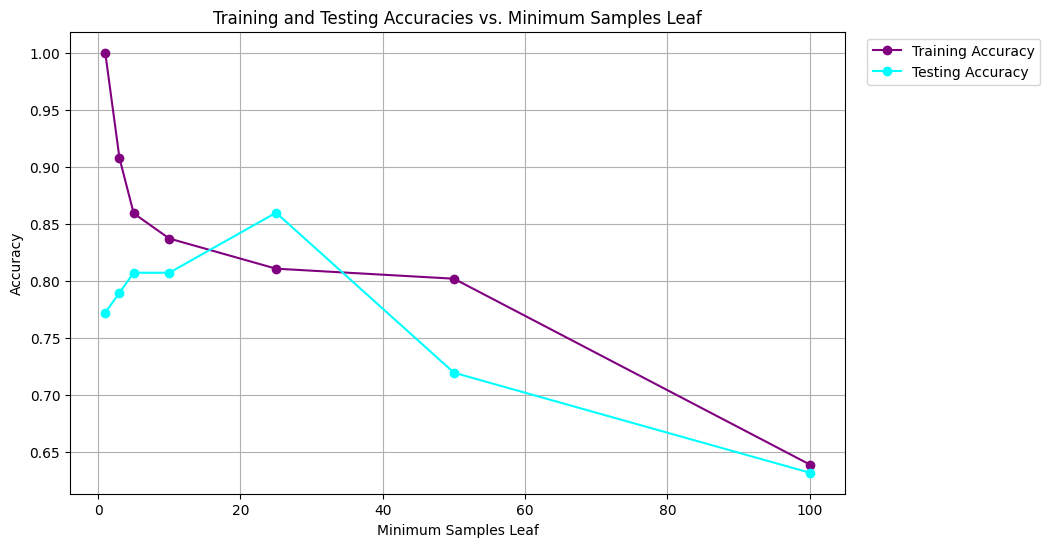

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(min_samples_leaf, training_accuracies, label='Training Accuracy', color='purple', marker='o')
plt.plot(min_samples_leaf, testing_accuracies, label='Testing Accuracy', color='cyan', marker='o')
plt.xlabel('Minimum Samples Leaf')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracies vs. Minimum Samples Leaf')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()

2) [2v] Critically analyze these results, including the generalization capacity across settings.

Análise Crítica dos Resultados:
Ao examinar os resultados obtidos através da análise de precisão de treino e teste em função do parâmetro min_samples_leaf da árvore de decisão, podemos tirar as seguintes conclusões:

Comportamento da Training Accuracy:
A Training Accuracy decresce continuamente à medida que o valor de min_samples_leaf aumenta. Este comportamento é esperado, pois valores baixos deste parâmetro permitem que a árvore crie folhas com poucos exemplos, aumentando a sua capacidade de capturar padrões específicos e detalhados dos dados de treino. Com menos restrições nas folhas, o modelo consegue ajustar-se mais precisamente aos dados, levando a uma precisão de treino mais elevada, próxima de 100% quando min_samples_leaf = 1.

Comportamento da Testing Accuracy:
A Testing Accuracy apresenta inicialmente um aumento significativo à medida que min_samples_leaf cresce de 1 para aproximadamente 25, atingindo o seu valor máximo (~86%). Este comportamento sugere que, até um determinado limite, a imposição de folhas com mais amostras força o modelo a aprender padrões mais gerais e robustos, melhorando a sua capacidade de generalização para novos dados. Um modelo que generaliza adequadamente é crucial, especialmente em aplicações do mundo real, pois garante que as previsões feitas em dados não vistos sejam precisas.

Overfitting:
Para valores muito baixos de min_samples_leaf (1-5), observa-se uma discrepância acentuada entre Training e Testing Accuracy (~20-28 pontos percentuais). Esta diferença é um sinal claro de overfitting, onde o modelo se torna excessivamente complexo e, consequentemente, começa a aprender não apenas os padrões nos dados, mas também o ruído, levando a um desempenho consideravelmente pior em dados que não foram vistos durante o treino. Essa complexidade adicional não se traduz num melhor desempenho de teste, mas sim numa pior capacidade de generalização.

Underfitting:
Após min_samples_leaf ultrapassar aproximadamente 25-30, ambas as accuracies começam a decrescer de forma acentuada. Este comportamento indica underfitting, onde o modelo se torna demasiado simples e perde a capacidade de capturar relações relevantes nos dados. Para valores muito elevados (~100), as accuracies convergem para aproximadamente 64%, demonstrando que a regularização excessiva prejudica tanto a capacidade de aprendizagem como a de generalização.

Pico de Testing Accuracy:
O ponto em que a Testing Accuracy é máxima (aproximadamente em min_samples_leaf = 25) representa a capacidade de generalização ideal do modelo. Neste estágio, o modelo equilibra adequadamente a complexidade e o desempenho em dados não vistos, apresentando um gap mínimo entre treino e teste. Qualquer diminuição adicional neste parâmetro leva a overfitting, enquanto aumentos excessivos resultam em underfitting.

Recomendações para Melhoria:
Para otimizar a capacidade de generalização, é crucial selecionar um valor de min_samples_leaf que minimize tanto o risco de overfitting como de underfitting. A análise sugere que um valor em torno de 25 é ideal, pois proporciona um equilíbrio entre a complexidade do modelo e a precisão de teste. Essa escolha assegura que o modelo é suficientemente robusto para aprender padrões significativos sem se deixar levar por variações aleatórias dos dados de treino. Adicionalmente, recomenda-se a utilização de validação cruzada para confirmar a estabilidade deste valor ótimo e considerar a otimização conjunta de outros hiperparâmetros da árvore para potencialmente melhorar ainda mais o desempenho. 

3) [4v] A healthcare provider requested the development of a predictive model achieving at least 80% validation accuracy and 78.5% test accuracy. The dataset must be split into training, validation, and testing sets (60–20–20), using a stratified split. The goal is to identify a model that satisfies the required accuracy within the following hyperparameter ranges: max_depth ∈ [2,4] and min_samples_split ∈ [2,100]. All other hyperparameters should be kept at their default values. Use random_state = 1 to split the data and to create the model.

i. Plot the decision tree.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# 1. Dividir o dataset em treino (60%), validação (20%) e teste (20%) com estratificação
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)
# (0.25 de 0.8 = 0.2, logo 60/20/20)
best_val_acc = 0
best_test_acc = 0
best_params = None
best_model = None


Melhor modelo: max_depth=4, min_samples_split=8
Validation accuracy: 0.877
Test accuracy: 0.825


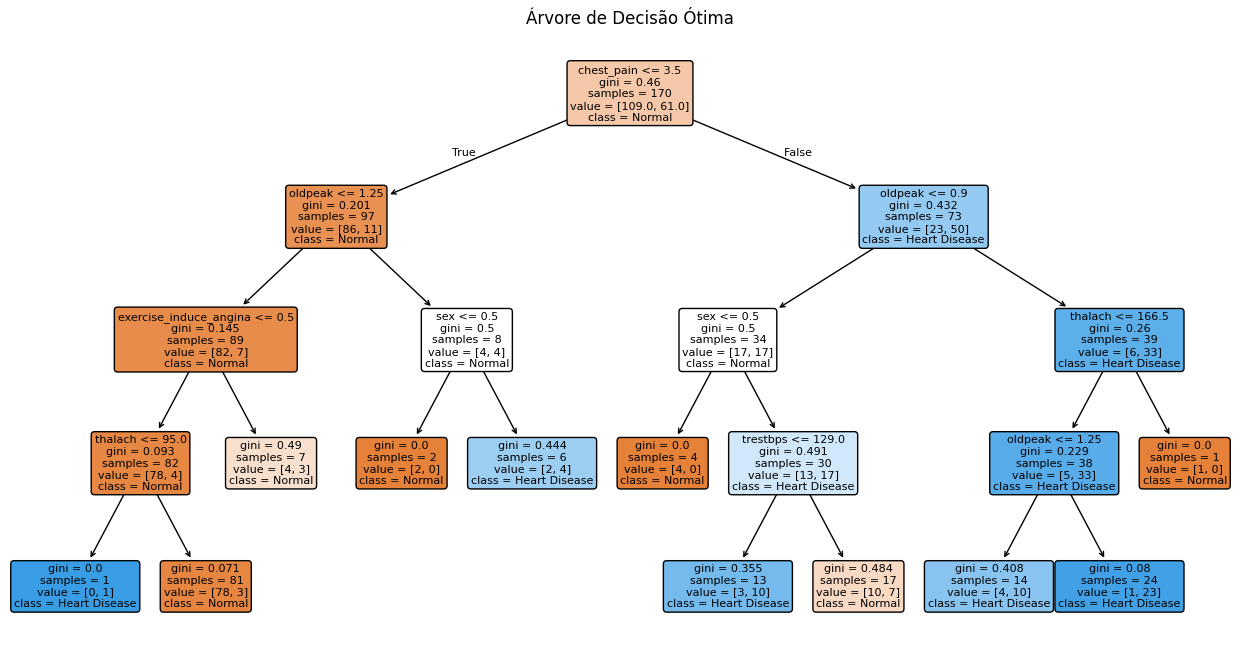

In [11]:
# 2. Grid search para max_depth e min_samples_split
for max_depth in range(2, 5):
    for min_samples_split in range(2, 101):
        clf = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=1)
        clf.fit(X_train, y_train)
        val_acc = accuracy_score(y_val, clf.predict(X_val))
        test_acc = accuracy_score(y_test, clf.predict(X_test))
        if val_acc >= 0.80 and test_acc >= 0.785:
            if val_acc > best_val_acc or (val_acc == best_val_acc and test_acc > best_test_acc):
                best_val_acc = val_acc
                best_test_acc = test_acc
                best_params = (max_depth, min_samples_split)
                best_model = clf

if best_model is not None:
    print(f"Melhor modelo: max_depth={best_params[0]}, min_samples_split={best_params[1]}")
    print(f"Validation accuracy: {best_val_acc:.3f}")
    print(f"Test accuracy: {best_test_acc:.3f}")
# 3. Plot da árvore de decisão
    plt.figure(figsize=(16, 8))
    plot_tree(best_model, feature_names=X.columns, class_names=['Normal', 'Heart Disease'], filled=True, rounded=True, fontsize=8)
    plt.title("Árvore de Decisão Ótima")
    plt.show()

ii. Explain what characterizes heart diseases by identifying the conditional associations together with their posterior probabilities.

In [12]:
import numpy as np

tree = best_model.tree_
feat = X.columns

def leaf_rules(node=0, conds=[]):
    if tree.children_left[node] == tree.children_right[node]:          # folha
        n = int(tree.n_node_samples[node])
        props = tree.value[node][0]
        cls = int(np.argmax(props)); post = props[cls] / props.sum()
        n_cls = round(post * n)
        label = ['Normal', 'Heart Disease'][cls]
        rule = " AND ".join(conds) if conds else "(raiz)"
        print(f"SE {rule}\n   => {label}  (posterior = {n_cls}/{n} = {post:.1%})\n")
        return
    f = feat[tree.feature[node]]; thr = tree.threshold[node]
    leaf_rules(tree.children_left[node],  conds + [f"{f} <= {thr:.2f}"])
    leaf_rules(tree.children_right[node], conds + [f"{f} > {thr:.2f}"])

leaf_rules()

SE chest_pain <= 3.50 AND oldpeak <= 1.25 AND exercise_induce_angina <= 0.50 AND thalach <= 95.00
   => Heart Disease  (posterior = 1/1 = 100.0%)

SE chest_pain <= 3.50 AND oldpeak <= 1.25 AND exercise_induce_angina <= 0.50 AND thalach > 95.00
   => Normal  (posterior = 78/81 = 96.3%)

SE chest_pain <= 3.50 AND oldpeak <= 1.25 AND exercise_induce_angina > 0.50
   => Normal  (posterior = 4/7 = 57.1%)

SE chest_pain <= 3.50 AND oldpeak > 1.25 AND sex <= 0.50
   => Normal  (posterior = 2/2 = 100.0%)

SE chest_pain <= 3.50 AND oldpeak > 1.25 AND sex > 0.50
   => Heart Disease  (posterior = 4/6 = 66.7%)

SE chest_pain > 3.50 AND oldpeak <= 0.90 AND sex <= 0.50
   => Normal  (posterior = 4/4 = 100.0%)

SE chest_pain > 3.50 AND oldpeak <= 0.90 AND sex > 0.50 AND trestbps <= 129.00
   => Heart Disease  (posterior = 10/13 = 76.9%)

SE chest_pain > 3.50 AND oldpeak <= 0.90 AND sex > 0.50 AND trestbps > 129.00
   => Normal  (posterior = 10/17 = 58.8%)

SE chest_pain > 3.50 AND oldpeak > 0.90 AND 

Caracterização de Doenças Cardíacas através da Árvore de Decisão Ótima
Com base na árvore de decisão ótima (profundidade máxima = 4, mínimo de amostras para divisão = 8), que alcançou uma accuracy de validação de 87,7% e de teste de 82,5%, podemos identificar as associações condicionais que caracterizam as doenças cardíacas e as suas probabilidades posteriores.

Principais Fatores Preditivos:
A análise da árvore revela que as doenças cardíacas são caracterizadas por uma combinação específica de condições clínicas, com destaque para os seguintes fatores:

1. Dor no Peito (chest_pain):
A variável chest_pain emerge como o fator mais discriminante na raiz da árvore, sendo a primeira divisão. Valores de dor no peito superiores a 3,5 (dor assintomática) direcionam para o ramo onde predominam casos de doença cardíaca (50 de 73 amostras, ~68%). Por outro lado, valores iguais ou inferiores a 3,5 indicam forte associação com a ausência de doença (classe Normal), com 86 de 97 amostras (~89%) desse ramo classificadas como Normal, sugerindo que tipos específicos ou intensidades de dor torácica são indicadores críticos.

2. Oldpeak (Depressão do Segmento ST):
Para indivíduos com chest_pain > 3.5, o parâmetro oldpeak torna-se crucial: oldpeak <= 0.9 ainda permite recuperar casos Normais, mas oldpeak > 0.9 combinado com thalach <= 166.5 leva a classificações consistentes de Heart Disease.

3. Thalach (Frequência Cardíaca Máxima):
A frequência cardíaca máxima alcançada (thalach) também demonstra ser um preditor significativo. Valores de thalach <= 166.5 estão associados a maior probabilidade de doença cardíaca. Este padrão é consistente com o conhecimento clínico de que pacientes com doença cardíaca frequentemente apresentam menor capacidade de atingir frequências cardíacas elevadas durante exercício físico.

4. Sexo (sex):
O sexo aparece em múltiplos níveis da árvore, sugerindo interação entre o género e outros fatores de risco. O sexo masculino (sex > 0.5) está associado a maior prevalência de doença (43,8% vs 15,8% no feminino); em vários ramos, sex <= 0.5 conduz consistentemente à classe Normal (100%), enquanto sex > 0.5 empurra a classificação para Heart Disease.

5. Outros Indicadores:
Variáveis como exercise_induce_angina (angina induzida por exercício), thalach (frequência cardíaca máxima) e trestbps (pressão arterial em repouso) aparecem em níveis subsequentes da árvore, refinando as classificações e demonstrando que a caracterização de doença cardíaca resulta de uma interação complexa de múltiplos fatores clínicos.

Probabilidades Posteriores e Confiança das Classificações:
Analisando os nós terminais da árvore, podemos observar diferentes níveis de confiança nas classificações:

Alta confiança para Normal: os ramos que conduzem à classe Normal atingem posteriores muito elevadas. O nó de maior peso resulta de chest_pain ≤ 3.5, oldpeak ≤ 1.25, exercise_induce_angina ≤ 0.5 e thalach > 95, que classifica Normal com 96,3% (78 de 81 amostras) e gini ≈ 0,07. Existem ainda folhas perfeitamente puras (gini = 0, posterior de 100%), embora com poucas amostras, como chest_pain > 3.5, oldpeak ≤ 0.9 e sex ≤ 0.5, que classifica como Normal as suas 4 amostras.

Alta confiança para Heart Disease: no ramo direito da árvore surgem folhas com elevada certeza diagnóstica. O caso mais marcante é chest_pain > 3.5, oldpeak > 0.9, thalach ≤ 166.5 e oldpeak > 1.25, que classifica Heart Disease com 95,8% (23 de 24 amostras) e gini ≈ 0,08, indicando um perfil de risco muito consistente.

Classificações com incerteza moderada: outras folhas apresentam heterogeneidade assinalável, com gini na ordem de 0,4 a 0,5, onde a probabilidade posterior não é tão definida. É o caso de chest_pain > 3.5, oldpeak ≤ 0.9, sex > 0.5 e trestbps > 129, que classifica Normal com apenas 58,8% (10 de 17 amostras), sugerindo casos de difícil classificação ou atípicos.

Padrões de Associação Condicional:
A estrutura hierárquica da árvore revela padrões condicionais importantes:

Padrão de Baixo Risco: chest_pain <= 3.5 ∧ oldpeak <= 1.25 ∧ exercise_induce_angina <= 0.5 ∧ thalach > 95 ⇒ Normal com posterior 96,3% (78/81).

Padrão de Alto Risco: chest_pain > 3.5 ∧ oldpeak > 0.9 ∧ thalach <= 166.5 ∧ oldpeak > 1.25 ⇒ Heart Disease com posterior 95,8% (23/24); já chest_pain > 3.5 ∧ oldpeak > 0.9 ∧ thalach > 166.5 ⇒ Normal, 100%

Padrão Intermédio: Casos com chest_pain <= 3.5 mas oldpeak baixo requerem análise adicional de outras variáveis (como exercise_induce_angina) para classificação definitiva.

Interpretação Clínica:
Os resultados demonstram que a presença de doença cardíaca não é determinada por um único fator, mas sim por combinações específicas de indicadores clínicos. A árvore de decisão captura estas interações de forma interpretável, identificando regras condicionais que podem auxiliar no diagnóstico. A accuracy de teste de 82,5% indica que o modelo generaliza adequadamente, embora existam casos onde a complexidade da doença cardíaca não é completamente capturada pelas variáveis disponíveis, justificando os 17,5% de erro residual.